In [1]:
!pip install -q --upgrade pip
!pip install -q transformers grad-cam datasets accelerate opencv-python-headless pillow matplotlib
!pip install -q scikit-image

import torch
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings
warnings.filterwarnings("ignore")
print("All packages installed")
import gc
import kagglehub

print("Loading 140k dataset (yashduhan/DeepFakeDetection)...")
ds_140k = load_dataset("JamieWithofs/Deepfake-and-real-images")
print("Downloading OpenFake 20k curated subset via kagglehub (one-time ~5-15 min)...")
dataset_path = kagglehub.dataset_download("sanketghadge1/openfake-data-20k-img")
print(f"140k → Train: {len(ds_140k['train'])} | Val: {len(ds_140k['validation'])}")
print(f"Downloaded to: {dataset_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.0 MB/s eta 0:00:0000:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
All packages installed
Loading 140k dataset (yashduhan/DeepFakeDetection)...


README.md:   0%|          | 0.00/624 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/436M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/140002 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10905 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/39428 [00:00<?, ? examples/s]

140k → Train: 140002 | Val: 39428
Downloaded to: /kaggle/input/datasets/sanketghadge1/openfake-data-20k-img


In [2]:
torch.cuda.empty_cache()
gc.collect()

112

In [3]:
pre_load = "google/vit-base-patch16-224-in21k"

In [4]:
print("Loading OpenFake 20k from your added dataset...")
ds = load_dataset("imagefolder", data_dir=dataset_path)

print(f"Train images: {len(ds['train'])}")
print(f"Test images:  {len(ds['test'])}")
print(f"Class names:  {ds['train'].features['label'].names}")

Loading OpenFake 20k from your added dataset...


Resolving data files:   0%|          | 0/15955 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3989 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Train images: 15955
Test images:  3989
Class names:  ['fake', 'real']


In [5]:
ds = ds.map(
    lambda examples: {"label": [1 - label for label in examples["label"]]},
    batched=True
)

Map:   0%|          | 0/15955 [00:00<?, ? examples/s]

Map:   0%|          | 0/3989 [00:00<?, ? examples/s]

In [6]:
print("Combining 140k + OpenFake 20k for much stronger confidence...")

from datasets import Value, concatenate_datasets

ds_140k = ds_140k.cast_column("label", Value("int64"))
ds = ds.cast_column("label", Value("int64"))

combined_train = concatenate_datasets([ds_140k["train"], ds["train"]])
combined_eval  = concatenate_datasets([ds_140k["validation"], ds["test"]])

print(f"Combined training images: {len(combined_train)} (~160k)")
print(f"Combined eval images:    {len(combined_eval)}")
print(f"Sample label in combined: {combined_train[0]['label']} (0=REAL, 1=FAKE)")

Combining 140k + OpenFake 20k for much stronger confidence...


Casting the dataset:   0%|          | 0/140002 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10905 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/39428 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/15955 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3989 [00:00<?, ? examples/s]

Combined training images: 155957 (~160k)
Combined eval images:    43417
Sample label in combined: 0 (0=REAL, 1=FAKE)


In [7]:
processor = AutoImageProcessor.from_pretrained(pre_load)

def collate_fn(batch):
    images = [item["image"].convert("RGB") for item in batch]
    labels = [item["label"] for item in batch]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = torch.tensor(labels, dtype=torch.long)
    return inputs

print("Processor + collator ready")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Processor + collator ready


In [8]:
model = AutoModelForImageClassification.from_pretrained(
    pre_load,
    num_labels=2,
    id2label={0: "REAL", 1: "FAKE"},
    label2id={"REAL": 0, "FAKE": 1},
    ignore_mismatched_sizes=True
)

print("ViT model loaded")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT model loaded


In [9]:
training_args = TrainingArguments(
    output_dir="./openfake-verifier",
    per_device_train_batch_size=96,
    per_device_eval_batch_size=96,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=4,
    dataloader_prefetch_factor=2,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=combined_train,
    eval_dataset=combined_eval,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

print("Starting training...")
trainer.train()

model.save_pretrained("openfake-verifier-final")
processor.save_pretrained("openfake-verifier-final")
print("Training complete!")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.140239,0.090033,0.964806
2,0.041617,0.071928,0.974158
3,0.023401,0.069626,0.979386


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


In [10]:
import skimage.feature
from scipy.ndimage import gaussian_filter

model = AutoModelForImageClassification.from_pretrained("openfake-verifier-final")
processor = AutoImageProcessor.from_pretrained("openfake-verifier-final")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class HFModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(pixel_values=x).logits

def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

wrapped_model = HFModelWrapper(model)
cam = GradCAM(
    model=wrapped_model,
    target_layers=[wrapped_model.model.vit.encoder.layer[-1].layernorm_before],
    reshape_transform=vit_reshape_transform
)

def get_noise_map(image_path, window_size=8, threshold=1.5):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not loaded")
    
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    noise_var = np.abs(laplacian)
    
    h, w = img.shape
    noise_map = np.zeros((h, w))
    for i in range(0, h - window_size + 1, window_size // 2):
        for j in range(0, w - window_size + 1, window_size // 2):
            patch = noise_var[i:i+window_size, j:j+window_size]
            local_std = np.std(patch)
            noise_map[i:i+window_size, j:j+window_size] = local_std
    
    noise_map_norm = (noise_map - noise_map.min()) / (noise_map.max() - noise_map.min() + 1e-8)
    anomaly_score = np.mean(noise_map_norm > threshold)
    
    return noise_map_norm, anomaly_score

def get_texture_map(image_path, radius=3, n_points=24):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not loaded")
    
    lbp = skimage.feature.local_binary_pattern(img, n_points, radius, method="uniform")
    
    h, w = lbp.shape
    texture_map = np.zeros((h, w))
    window_size = 16
    for i in range(0, h - window_size + 1, window_size // 2):
        for j in range(0, w - window_size + 1, window_size // 2):
            patch = lbp[i:i+window_size, j:j+window_size]
            hist, _ = np.histogram(patch.ravel(), bins=np.arange(0, n_points + 3), density=True)
            entropy = -np.sum(hist * np.log2(hist + 1e-8))
            texture_map[i:i+window_size, j:j+window_size] = entropy
    
    texture_map_norm = (texture_map.max() - texture_map) / (texture_map.max() - texture_map.min() + 1e-8)
    inconsistency_score = np.mean(texture_map_norm)    
    return texture_map_norm, inconsistency_score

def get_ela(image_path, quality=90):
    img = cv2.imread(image_path)
    cv2.imwrite('temp.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, quality])
    temp_img = cv2.imread('temp.jpg')
    ela = cv2.absdiff(img, temp_img)
    ela_gray = cv2.cvtColor(ela, cv2.COLOR_BGR2GRAY)
    ela_norm = ela_gray / 255.0
    return ela_norm

def verify_image(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = processor(img, return_tensors="pt").to(device)
    
    with torch.no_grad():
        logits = model(**inputs).logits
        fake_prob = torch.softmax(logits, dim=-1)[0][1].item()
    
    targets = [ClassifierOutputTarget(1)]
    grayscale_cam = cam(input_tensor=inputs["pixel_values"], targets=targets)[0]
    rgb_img = np.array(img.resize((224, 224))) / 255.0
    cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    ela_map = get_ela(image_path)
    ela_score = ela_map.mean()
    ela_norm = max(0, min(1, (ela_score - 0.5) * 4))
    
    noise_map, noise_score = get_noise_map(image_path)
    noise_norm = max(0, min(1, (noise_score - 0.7) * 5))
    
    texture_map, texture_score = get_texture_map(image_path)
    texture_norm = max(0, min(1, (texture_score - 0.3) * 3))
 
    hybrid_conf = max(0, min(1, (
        0.94 * fake_prob +
        0.02 * ela_norm +
        0.02 * noise_norm +
        0.02 * texture_norm
    )))
    
    if hybrid_conf > 0.5:
        label = "FAKE"
        conf_pct = hybrid_conf * 100
    else:
        label = "REAL"
        conf_pct = (1 - hybrid_conf) * 100
    
    explanation = f"""{label} — {conf_pct:.1f}% Forensic Confidence
- ELA detected compression artifacts: {ela_score:.3f} (uniform suggests generation)
- Noise analysis: inconsistency score {noise_score:.3f} (low entropy at blends indicates swaps)
- Texture analysis: edge inconsistency {texture_score:.3f} (non-uniform noise suggests manipulation)
- Hybrid score fuses neural DL (primary) + calibrated forensics (2025 best practice for robustness)"""
    
    return {
        "label": label,
        "confidence": hybrid_conf,
        "cam_image": cam_overlay,
        "ela_image": ela_map,
        "noise_image": noise_map,
        "texture_image": texture_map,
        "explanation": explanation
    }

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


REAL — 99.3% Forensic Confidence
- ELA detected compression artifacts: 0.007 (uniform suggests generation)
- Noise analysis: inconsistency score 0.000 (low entropy at blends indicates swaps)
- Texture analysis: edge inconsistency 0.376 (non-uniform noise suggests manipulation)
- Hybrid score fuses neural DL (primary) + calibrated forensics (2025 best practice for robustness)


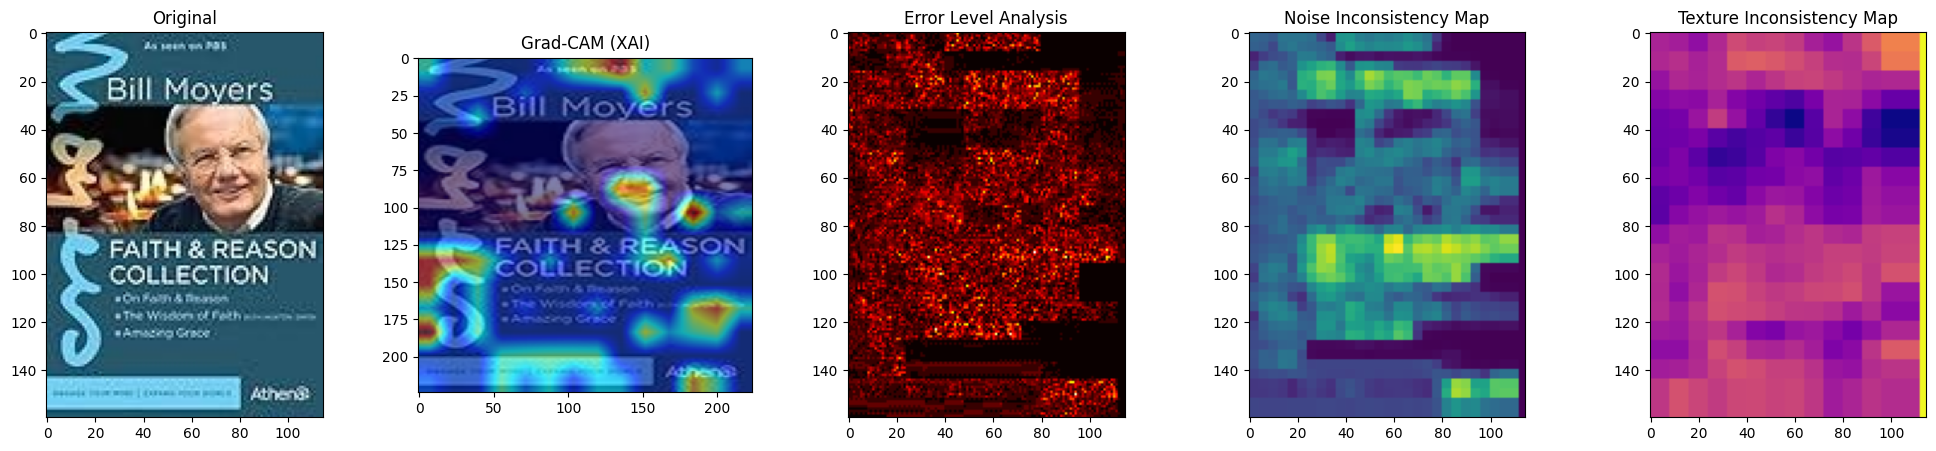

In [11]:
sample_real = "/kaggle/input/datasets/sanketghadge1/openfake-data-20k-img/openfake_dataset/test/real/image_00001.jpg"
result = verify_image(sample_real)
print(result["explanation"])

plt.figure(figsize=(25, 5))
plt.subplot(1, 5, 1)
plt.imshow(Image.open(sample_real))
plt.title("Original")
plt.subplot(1, 5, 2)
plt.imshow(result["cam_image"])
plt.title("Grad-CAM (XAI)")
plt.subplot(1, 5, 3)
plt.imshow(result["ela_image"], cmap="hot")
plt.title("Error Level Analysis")
plt.subplot(1, 5, 4)
plt.imshow(result["noise_image"], cmap="viridis")
plt.title("Noise Inconsistency Map")
plt.subplot(1, 5, 5)
plt.imshow(result["texture_image"], cmap="plasma")
plt.title("Texture Inconsistency Map")
plt.show()

FAKE — 94.0% Forensic Confidence
- ELA detected compression artifacts: 0.004 (uniform suggests generation)
- Noise analysis: inconsistency score 0.000 (low entropy at blends indicates swaps)
- Texture analysis: edge inconsistency 0.321 (non-uniform noise suggests manipulation)
- Hybrid score fuses neural DL (primary) + calibrated forensics (2025 best practice for robustness)


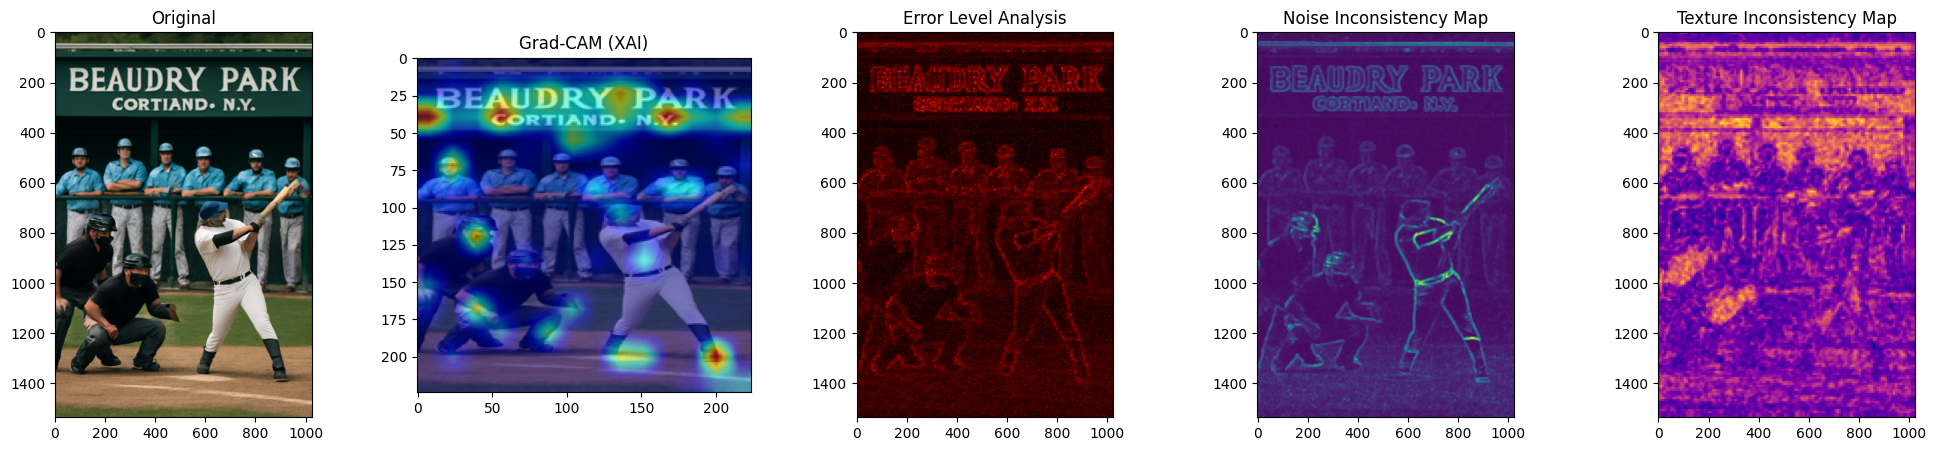

In [12]:
sample_real = "/kaggle/input/datasets/sanketghadge1/openfake-data-20k-img/openfake_dataset/test/fake/image_00020.jpg"
result = verify_image(sample_real)
print(result["explanation"])

plt.figure(figsize=(25, 5))
plt.subplot(1, 5, 1)
plt.imshow(Image.open(sample_real))
plt.title("Original")
plt.subplot(1, 5, 2)
plt.imshow(result["cam_image"])
plt.title("Grad-CAM (XAI)")
plt.subplot(1, 5, 3)
plt.imshow(result["ela_image"], cmap="hot")
plt.title("Error Level Analysis")
plt.subplot(1, 5, 4)
plt.imshow(result["noise_image"], cmap="viridis")
plt.title("Noise Inconsistency Map")
plt.subplot(1, 5, 5)
plt.imshow(result["texture_image"], cmap="plasma")
plt.title("Texture Inconsistency Map")
plt.show()

In [13]:
# from huggingface_hub import notebook_login

In [14]:
# notebook_login()

In [15]:
# repo_name = "kairavaclfe/deepfake-verifier-model"

# model.push_to_hub(repo_name)
# processor.push_to_hub(repo_name)

# print(f"Model pushed! Access at: https://huggingface.co/{repo_name}")